In [15]:
## necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# packages for OLS
import statsmodels.api as sm
# packages for Lasso and Ridge
from sklearn.linear_model import Lasso, Ridge
# packages for cross validation
from sklearn.model_selection import train_test_split, cross_val_score
# packages for evaluation metrics


In [16]:
import pmdarima as pm

### Data importing and Cleaning

In [17]:
# read data
data1 = pd.read_excel("/Users/geoffpoint-du-jour/Downloads/Forecasting/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx")
loandata = pd.read_csv("BUSLOANS.CSV")
cpi = pd.read_csv("CPI.csv")
unemployment = pd.read_csv("UNEMPLOYMENT.csv")

In [18]:
data1.describe()

,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
count,174119.000000,17766.000000,17766.000000,17766.000000,17766.000000,173593.000000,17766.000000,17766.000000,17766.000000,17766.000000,...,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000
mean,95.236762,840.967060,866.092443,891.087843,917.006110,108.933840,969.639685,996.338306,1022.676059,1049.292877,...,3127.281510,3163.518732,3201.570250,3242.751005,3285.449618,3328.596394,3370.754859,3412.454024,3452.267658,3489.628947
std,2289.750694,7307.534944,7535.206910,7761.007686,7993.573881,2665.725873,8463.375885,8700.701152,8934.736738,9170.846646,...,27268.459557,27585.451116,27917.904010,28276.030559,28646.450299,29020.727551,29387.234932,29750.197432,30098.085245,30426.271405
min,-943.333400,-2.092654,-4.364267,-6.741271,-8.660476,-943.333400,-12.707780,-14.835680,-16.965630,-19.100350,...,-81.798450,-82.253550,-82.752540,-83.052440,-83.340140,-83.636070,-83.953930,-84.303440,-84.606930,-84.979890
25%,0.000000,-0.579394,-1.145731,-1.713888,-2.196124,0.000000,-3.080627,-3.466194,-3.909014,-4.286945,...,-9.865396,-9.981096,-10.022375,-9.967483,-9.885205,-9.745334,-9.670343,-9.572050,-9.547108,-9.553268
50%,0.006200,3.551642,4.440057,5.378792,5.805345,0.009100,6.611908,7.486106,8.135852,8.551282,...,27.193900,27.320940,27.527850,27.673905,27.654960,27.789595,27.983630,28.079895,28.304590,28.493520
75%,0.353400,164.802850,169.163125,163.364550,168.849250,0.442900,185.604725,192.341550,199.239550,209.005275,...,821.159900,828.797350,841.240500,855.047225,864.447725,875.365525,882.492400,892.358800,899.330625,903.313425
max,114983.700000,119390.500000,123735.100000,128030.200000,132300.000000,136556.300000,141062.500000,145617.200000,150189.600000,154795.100000,...,518460.000000,525323.000000,532328.200000,539488.600000,546723.000000,553987.700000,561212.700000,568369.900000,575400.300000,582255.800000


In [19]:
loandata.tail() # data is 1947 to present

,observation_date,BUSLOANS
944,2025-09-01,2693.7380
945,2025-10-01,2692.3125
946,2025-11-01,2698.5199
947,2025-12-01,2709.2908
948,2026-01-01,2743.0472


In [20]:
# take a look into unemploymenbt
unemployment.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [21]:
# do a regression with loandata as the dependent variable and unemployment as the independent variable
# merge the two datasets on the date column
# convert date columns to datetime
loandata['Date'] = pd.to_datetime(loandata['observation_date'])
unemployment['Date'] = pd.to_datetime(unemployment['observation_date'])
# merge datasets
merged_data = pd.merge(loandata, unemployment, on='observation_date', how='inner')
# check the merged data
merged_data.head()


,observation_date,BUSLOANS,Date_x,UNRATE,Date_y
0,1948-01-01,14.4049,1948-01-01,3.4,1948-01-01
1,1948-02-01,14.5635,1948-02-01,3.8,1948-02-01
2,1948-03-01,14.7454,1948-03-01,4.0,1948-03-01
3,1948-04-01,14.9301,1948-04-01,3.9,1948-04-01
4,1948-05-01,15.0976,1948-05-01,3.5,1948-05-01


In [22]:
## read NiGEM data
nigem = pd.read_excel("NiGEM_data.xlsx")

In [23]:
nigem['Region'].unique()

array(['NiGEM NGFS v1.24.2|Africa', 'NiGEM NGFS v1.24.2|Argentina',
       'NiGEM NGFS v1.24.2|Asia', 'NiGEM NGFS v1.24.2|Australia',
       'NiGEM NGFS v1.24.2|Austria', 'NiGEM NGFS v1.24.2|Belgium',
       'NiGEM NGFS v1.24.2|Brazil', 'NiGEM NGFS v1.24.2|Bulgaria',
       'NiGEM NGFS v1.24.2|Canada', 'NiGEM NGFS v1.24.2|Chile',
       'NiGEM NGFS v1.24.2|China', 'NiGEM NGFS v1.24.2|Croatia',
       'NiGEM NGFS v1.24.2|Czech Republic', 'NiGEM NGFS v1.24.2|Denmark',
       'NiGEM NGFS v1.24.2|Developing Europe', 'NiGEM NGFS v1.24.2|Egypt',
       'NiGEM NGFS v1.24.2|Estonia', 'NiGEM NGFS v1.24.2|Europe',
       'NiGEM NGFS v1.24.2|Finland', 'NiGEM NGFS v1.24.2|France',
       'NiGEM NGFS v1.24.2|Germany', 'NiGEM NGFS v1.24.2|Greece',
       'NiGEM NGFS v1.24.2|Hong Kong', 'NiGEM NGFS v1.24.2|Hungary',
       'NiGEM NGFS v1.24.2|India', 'NiGEM NGFS v1.24.2|Indonesia',
       'NiGEM NGFS v1.24.2|Ireland', 'NiGEM NGFS v1.24.2|Italy',
       'NiGEM NGFS v1.24.2|Japan', 'NiGEM NGFS v1.24.2|

In [24]:
nigem.head()
## filter Region for United States
nigem = nigem[nigem['Region'] == 'NiGEM NGFS v1.24.2|United States']

In [25]:
nigem["Variable"].unique()

array(['Carbon pricing ; $ per Tn CO2(combined(no bus))',
       'Carbon pricing ; $ per Tn CO2(combined)',
       'Carbon pricing ; $ per Tn CO2(physical)',
       'Carbon pricing ; $ per Tn CO2(transition)',
       'Central bank Intervention rate (policy interest rate) ; %(combined(no bus))',
       'Central bank Intervention rate (policy interest rate) ; %(combined)',
       'Central bank Intervention rate (policy interest rate) ; %(physical)',
       'Central bank Intervention rate (policy interest rate) ; %(transition)',
       'Coal price ; US$ per barrel (equiv)(combined(no bus))',
       'Coal price ; US$ per barrel (equiv)(combined)',
       'Coal price ; US$ per barrel (equiv)(physical)',
       'Coal price ; US$ per barrel (equiv)(transition)',
       'Consumption (private)(combined(no bus))',
       'Consumption (private)(combined)',
       'Consumption (private)(physical)',
       'Consumption (private)(transition)',
       'Domestic demand(combined(no bus))', 'Domestic de

In [26]:
## filter Variable column for any variable that contains combined
nigem = nigem[nigem['Variable'].str.contains('combined', case=False, na=False)]
nigem.info()

<class 'pandas.core.frame.DataFrame'>
Index: 756 entries, 6772 to 100656
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Model     756 non-null    object 
 1   Scenario  756 non-null    object 
 2   Region    756 non-null    object 
 3   Variable  756 non-null    object 
 4   Unit      756 non-null    object 
 5   2022      756 non-null    float64
 6   2023      756 non-null    float64
 7   2024      756 non-null    float64
 8   2025      756 non-null    float64
 9   2026      756 non-null    float64
 10  2027      756 non-null    float64
 11  2028      756 non-null    float64
 12  2029      756 non-null    float64
 13  2030      756 non-null    float64
 14  2031      756 non-null    float64
 15  2032      756 non-null    float64
 16  2033      756 non-null    float64
 17  2034      756 non-null    float64
 18  2035      756 non-null    float64
 19  2036      756 non-null    float64
 20  2037      756 non-null    float

In [27]:
## standardize frequency of all data to quarterly


## Data analysis

In [28]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear') 

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           2.284590   
2023-06-30                                           4.326648   
2023-09-30                                           6.117294   
2023-12-31                                           7.632591   
2024-03-31                                           8.860540   
2024-06-30                                           9.819093   
2024-09-30                                          10.416909   
2024-12-31                                          10.540245   
2025-03-31                                          10.201768   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

In [29]:
ngfs_quarterly.head()

,Below 2°C_Carbon pricing ; $ per Tn CO2(combined),Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined),Below 2°C_Coal price ; US$ per barrel (equiv)(combined),Below 2°C_Consumption (private)(combined),Below 2°C_Domestic demand(combined),Below 2°C_Effective exchange rate(combined),Below 2°C_Energy consumption (total) ; MnToe(combined),Below 2°C_Equity prices(combined),Below 2°C_Exports (goods and services)(combined),Below 2°C_Gas price ; US$ per barrel (equiv)(combined),...,Net Zero 2050_Productivity (output per hour worked); US$ Bn(combined),Net Zero 2050_Quarterly consumption of coal ; MnToe(combined),Net Zero 2050_Quarterly consumption of gas ; MnToe(combined),Net Zero 2050_Quarterly consumption of non-carbon ; MnToe(combined),Net Zero 2050_Quarterly consumption of oil ; MnToe(combined),Net Zero 2050_Real personal disposable income(combined),Net Zero 2050_Revenue from CB or BCA tax; US$ Bn(combined),Net Zero 2050_Trend output for capacity utilisation(combined),Net Zero 2050_Unemployment rate ; %(combined),Net Zero 2050_Volume energy use as a share of GDP ; Bn US$(PPP)(combined)
Year,,,,,,,,,,,,,,,,,,,,,
2022-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-03-31,2.284590,0.149448,1.168305,-0.416583,-0.397950,-0.187632,-0.204663,-1.259301,0.107286,0.281689,...,-0.405065,-1.078041,-0.419391,0.455331,-0.550529,-0.313348,86.553847,-0.388097,-0.076737,-0.239451
2023-06-30,4.326648,0.260358,2.230487,-0.783507,-0.761184,-0.348465,-0.383259,-2.311035,0.176401,0.565066,...,-0.781149,-2.027625,-0.788083,0.851298,-1.030559,-0.707187,161.660341,-0.731607,-0.110575,-0.448197
2023-09-30,6.117294,0.331398,3.182598,-1.098973,-1.088403,-0.481542,-0.534848,-3.147855,0.206039,0.850083,...,-1.127142,-2.844097,-1.104239,1.185766,-1.437552,-1.184072,224.908129,-1.028909,-0.100063,-0.625131
2023-12-31,7.632591,0.361124,4.012299,-1.358644,-1.375397,-0.584935,-0.657310,-3.756967,0.195222,1.133619,...,-1.438725,-3.516237,-1.363500,1.454023,-1.765802,-1.740103,275.402556,-1.275956,-0.044585,-0.767774


### Model with NGFS scenario data

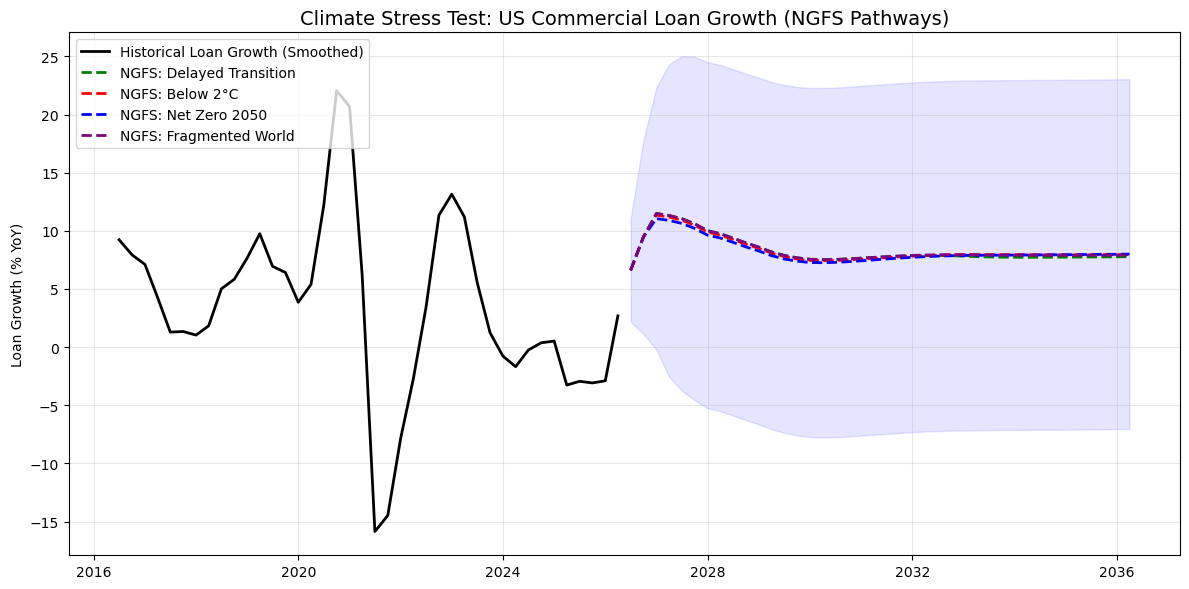

In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. & 2. (Kept your cleaning/loading logic)
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        return pd.DataFrame()

df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# 3. Smoothing (Kept your logic)
shock_start, shock_end = '2020-03-01', '2020-12-31'
df_history.loc[shock_start:shock_end, 'Loan_Growth'] = np.nan
df_history['Loan_Growth'] = df_history['Loan_Growth'].interpolate(method='linear') 
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear') 

# 4. Feature Engineering
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_train = df_history.dropna()

# 5. Train Model (Optimal ARIMA 2,0,2)
y = df_train['Loan_Growth']
X = df_train[['Unemployment_Lag1']]
model = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4)) 
model_fit = model.fit()

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS (Updated to use actual NGFS Data)
# ---------------------------------------------------------
forecast_steps = 40 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='QE')[1:]
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]

# NECESSARY CHANGE: Use NGFS Shocks instead of np.linspace
def build_ngfs_exog(scenario_prefix):
    # Find column
    col = [c for c in ngfs_quarterly.columns if scenario_prefix in c and "Unemployment" in c][0]
    shocks = ngfs_quarterly.loc[forecast_dates[0]:, col].head(forecast_steps)
    # Anchor to history
    future_path = last_actual_unemp + shocks #possibly make this a polynomial in the future
    # Combine & Lag
    full_series = pd.concat([df_history['Unemployment_Rate'], future_path])
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag1'] = full_series.shift(2).loc[forecast_dates]
    return X_f

X_future_delayed = build_ngfs_exog('Delayed transition')
X_future_stress = build_ngfs_exog('Below 2°C')
X_future_nz = build_ngfs_exog('Net Zero 2050')
X_future_fragmented = build_ngfs_exog('Fragmented World')

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
# Run all 3 scenarios through the model
forecast_delayed = model_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

forecast_nz = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
p_nz = forecast_nz.predicted_mean
conf_nz = forecast_nz.conf_int()

forecast_fragmented = model_fit.get_forecast(steps=forecast_steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
conf_fragmented = forecast_fragmented.conf_int()


# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))


# Plot History
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], 
         label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)

# NGFS Scenarios
plt.plot(pred_delayed.index, pred_delayed, 
         label='NGFS: Delayed Transition', color='green', linestyle='--', linewidth=2)

plt.plot(pred_stress.index, pred_stress, 
         label='NGFS: Below 2°C', color='red', linestyle='--', linewidth=2)

plt.plot(p_nz.index, p_nz, 
         label='NGFS: Net Zero 2050', color='blue', linestyle='--', linewidth=2)
plt.plot(pred_fragmented.index, pred_fragmented,
         label='NGFS: Fragmented World', color='purple', linestyle='--', linewidth=2)
# Shading for the Net Zero Scenario
plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)

plt.title('Climate Stress Test: US Commercial Loan Growth (NGFS Pathways)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##USING THIS MODEL 

In [31]:
# 1. Feature Engineering: Calculate Inflation from CPI
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100

# 2. Apply the Lag (Lag 2 to match Unemployment)
df_history['Inflation_Lag2'] = df_history['Inflation'].shift(2)

# 3. Drop NaNs and define the new feature list
df_train = df_history.dropna()
features = ['Unemployment_Lag1', 'Inflation_Lag2']

# 4. Re-Train the Model with TWO exogenous variables
y = df_train['Loan_Growth']
X = df_train[features]

print(f"Training SARIMAX with features: {features}")
model_multi = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4))
model_fit_multi = model_multi.fit()

print(model_fit_multi.summary())

Training SARIMAX with features: ['Unemployment_Lag1', 'Inflation_Lag2']
                                    SARIMAX Results                                     
Dep. Variable:                      Loan_Growth   No. Observations:                  307
Model:             ARIMA(2, 0, 2)x(1, 0, [], 4)   Log Likelihood                -688.351
Date:                          Sat, 04 Apr 2026   AIC                           1394.703
Time:                                  22:54:21   BIC                           1428.245
Sample:                              09-30-1949   HQIC                          1408.116
                                   - 03-31-2026                                         
Covariance Type:                            opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.6452      2.366     

## Multifeature model!

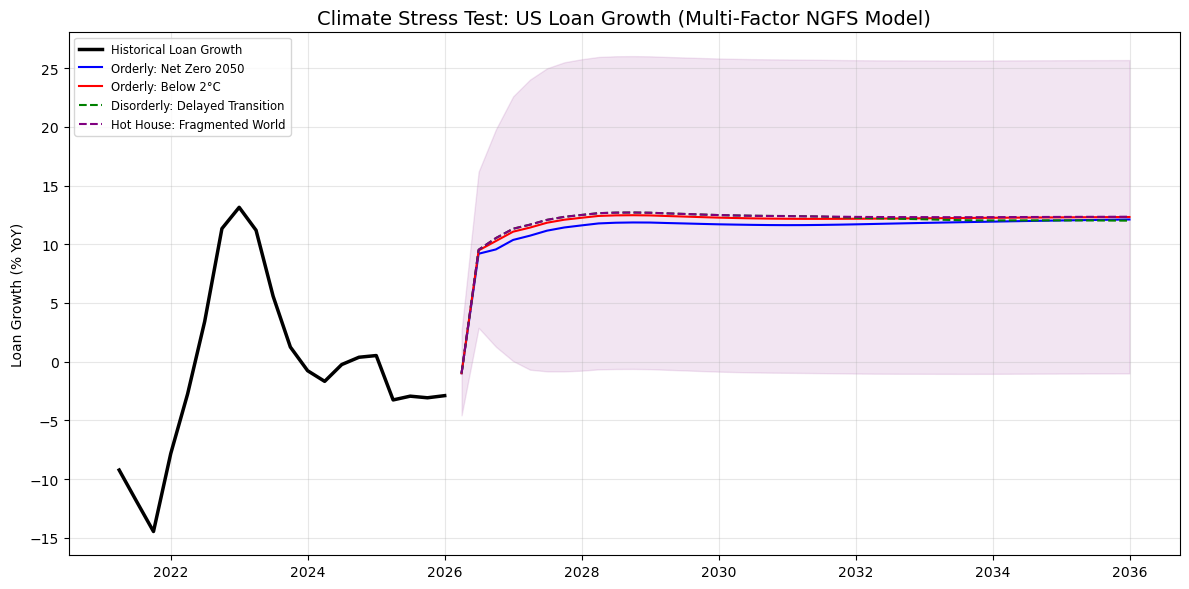

In [56]:
## FINAL MODEL: MULTI-FACTOR NGFS CLIMATE STRESS TEST (PROPERLY TRAINED)
##USE THIS MODEL!!! 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. CLEAN FRED DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception:
        return pd.DataFrame()

# Load ALL required data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')
df_rates = clean_fred_data('FEDFUNDS.csv', 'Rates')

# ---------------------------------------------------------
# 2. MERGE + TARGET VARIABLE
# ---------------------------------------------------------
df_history = pd.concat([
    df_loans, df_unemp, df_gdp, df_rates
], axis=1).dropna()

df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# ---------------------------------------------------------
# 3. SMOOTH COVID
# ---------------------------------------------------------
shock_start, shock_end = '2020-03-01', '2021-06-30'

for col in ['Loan_Growth', 'Unemployment_Rate']:
    df_history.loc[shock_start:shock_end, col] = np.nan
    df_history[col] = df_history[col].interpolate(method='linear')

# ---------------------------------------------------------
# 4. FEATURE ENGINEERING (CRITICAL UPGRADE)
# ---------------------------------------------------------
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_history['GDP_Lag1'] = df_history['GDP'].shift(1)
df_history['Rates_Lag1'] = df_history['Rates'].shift(1)
## Dummies added
outlier_dates = ['1981-03-31', '2008-12-31', '2009-03-31', '2023-03-31']
df_dummies = pd.DataFrame(0, index=df_history.index, columns=['Outlier_Shock'])
df_dummies.loc[df_dummies.index.isin(outlier_dates), 'Outlier_Shock'] = 1
df_history = pd.concat([df_history, df_dummies], axis=1)
df_train = df_history.dropna()



# ---------------------------------------------------------
# 5. TRAIN MODEL (NOW ACTUALLY MULTI-FACTOR)
# ---------------------------------------------------------
y = df_train['Loan_Growth']

X = df_train[['Unemployment_Lag1', 'GDP_Lag1', 'Rates_Lag1',"Outlier_Shock"]]

model = ARIMA(
    y,
    exog=X,
    order=(2, 0, 0),
    seasonal_order=(1, 0, 0, 4)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 6. FORECAST SETUP
# ---------------------------------------------------------
forecast_steps = 40
last_hist_date = df_history.index[-1]

forecast_dates = pd.date_range(
    start=last_hist_date,
    periods=forecast_steps + 1,
    freq='QE'
)[1:]

last_unemp = df_history['Unemployment_Rate'].iloc[-1]
last_gdp = df_history['GDP'].iloc[-1]
last_rates = df_history['Rates'].iloc[-1]

# ---------------------------------------------------------
# 7. NGFS HELPER
# ---------------------------------------------------------
def get_ngfs_series(scenario, keyword):
    cols = [c for c in ngfs_quarterly.columns if scenario in c and keyword in c]
    if len(cols) == 0:
        raise ValueError(f"{keyword} not found for {scenario}")
    return ngfs_quarterly[cols[0]]

# ---------------------------------------------------------
# 8. BUILD MULTI-FACTOR EXOG 
# ---------------------------------------------------------
def build_ngfs_exog_multi(scenario):

    unemp_shock = get_ngfs_series(scenario, "Unemployment")
    gdp_series = get_ngfs_series(scenario, "Gross Domestic Product")
    rate_series = get_ngfs_series(scenario, "Central bank") # interest rates

    # Align forecast horizon
    unemp_shock = unemp_shock.loc[forecast_dates[0]:].head(forecast_steps)
    gdp_series = gdp_series.loc[forecast_dates[0]:].head(forecast_steps)
    rate_series = rate_series.loc[forecast_dates[0]:].head(forecast_steps)

    # Anchor unemployment (shock-based)
    unemp_future = last_unemp + unemp_shock

    # GDP & Rates: assume levels already (NGFS provides levels or indexed paths)
    future = pd.DataFrame({
        'Unemployment_Rate': unemp_future.values,
        'GDP': gdp_series.values,
        'Rates': rate_series.values
    }, index=forecast_dates)

    # Combine with history for lagging
    full = pd.concat([df_history[['Unemployment_Rate','GDP','Rates']], future])

    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag1'] = full['Unemployment_Rate'].shift(2).loc[forecast_dates]
    X_f['GDP_Lag1'] = full['GDP'].shift(1).loc[forecast_dates]
    X_f['Rates_Lag1'] = full['Rates'].shift(1).loc[forecast_dates]
    X_f['Outlier_Shock'] = 0 # No outlier shocks in forecast period

    return X_f

# ---------------------------------------------------------
# 9. RUN ALL SCENARIOS
# ---------------------------------------------------------
scenarios = {
    "Net Zero 2050": "Orderly: Net Zero 2050",
    "Below 2°C": "Orderly: Below 2°C",
    "Delayed transition": "Disorderly: Delayed Transition",
    "Fragmented World": "Hot House: Fragmented World"
}

results = {}

for key in scenarios:
    X_future = build_ngfs_exog_multi(key)
    results[key] = model_fit.get_forecast(steps=forecast_steps, exog=X_future)

# ---------------------------------------------------------
# 10. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df_train.index[-20:],
    df_train['Loan_Growth'][-20:],
    label='Historical Loan Growth',
    color='black',
    linewidth=2.5
)

colors = {
    "Net Zero 2050": "blue",
    "Below 2°C": "red",
    "Delayed transition": "green",
    "Fragmented World": "purple"
}

linestyles = {
    "Net Zero 2050": "-",
    "Below 2°C": "-",
    "Delayed transition": "--",
    "Fragmented World": "--"
}

for key in results:
    plt.plot(
        forecast_dates,
        results[key].predicted_mean,
        label=scenarios[key],
        color=colors[key],
        linestyle=linestyles[key]
    )

# Confidence interval (worst case)
conf = results["Fragmented World"].conf_int()
plt.fill_between(
    forecast_dates,
    conf.iloc[:, 0],
    conf.iloc[:, 1],
    color='purple',
    alpha=0.1
)

plt.title('Climate Stress Test: US Loan Growth (Multi-Factor NGFS Model)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 

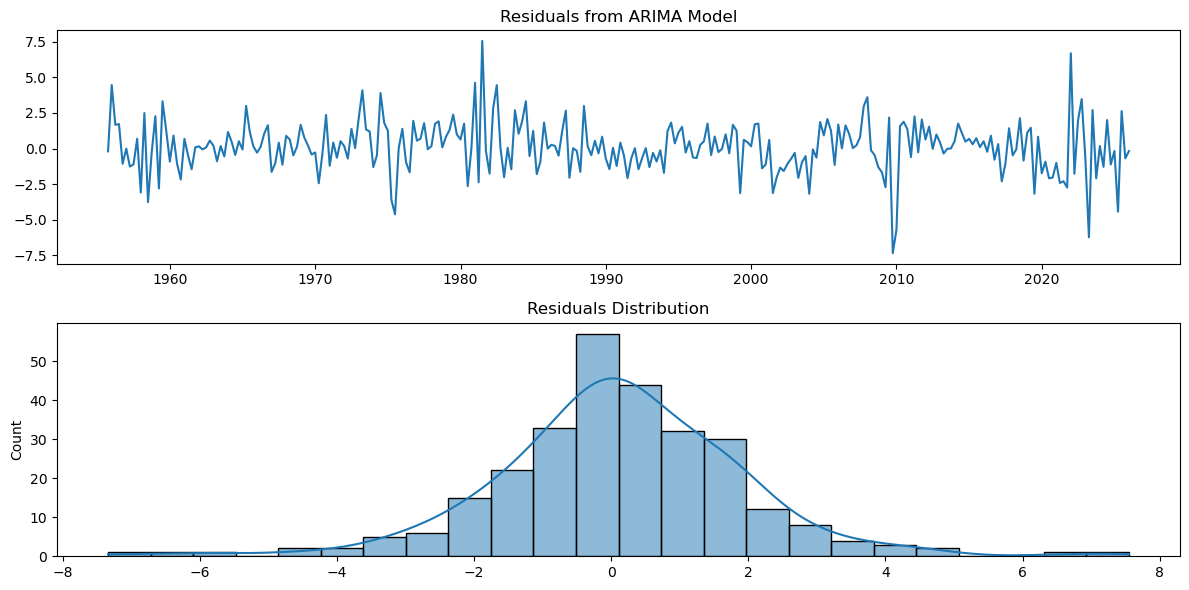

In [60]:
## residuals analysis
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals)
plt.title('Residuals from ARIMA Model')
plt.subplot(2, 1, 2)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.tight_layout()
plt.show()

In [58]:
# Check if the scenarios are actually different in the last quarter
for key in results:
    print(f"{key}: {results[key].predicted_mean.iloc[-1]:.4f}%")

Net Zero 2050: 12.1125%
Below 2°C: 12.3240%
Delayed transition: 12.0137%
Fragmented World: 12.3481%


In [59]:
# print model summary
print(model_fit.summary())


                                    SARIMAX Results                                    
Dep. Variable:                     Loan_Growth   No. Observations:                  282
Model:             ARIMA(2, 0, 0)x(1, 0, 0, 4)   Log Likelihood                -566.539
Date:                         Sat, 04 Apr 2026   AIC                           1151.078
Time:                                 23:14:06   BIC                           1183.855
Sample:                             09-30-1955   HQIC                          1164.222
                                  - 12-31-2025                                         
Covariance Type:                           opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                17.2341      4.003      4.305      0.000       9.388      25.080
Unemployment_Lag1    -1.0999      0.38

#### (2,0,2) vs (2,0,0)
##### The second model is statistically superior as it eliminates the insignificant moving average (MA) terms, resulting in a significant reduction in BIC from 1154 to 1106. Most importantly, it resolves the previous issue with residual autocorrelation, as evidenced by the Prob(Q) jumping from 0.01 to 0.31, confirming the model now captures the data's underlying temporal structure.

##### While the macro drivers like Unemployment and GDP remain robust predictors, Interest Rates lost significance in the second model, suggesting that loan growth momentum and seasonality are the primary internal drivers. However, the drop in Prob(JB) to 0.00 indicates that while the fit is better, the model still struggles with "fat tails" and non-normal residuals, likely due to recent economic volatility.

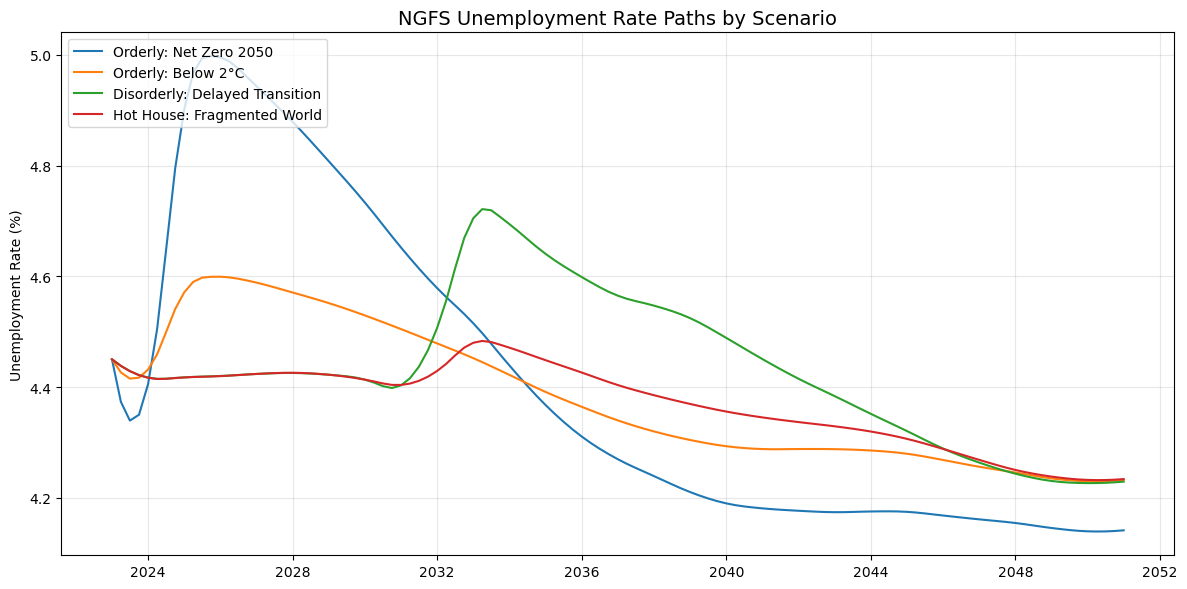

In [43]:
## plot the unemployment rate paths for each scenario to verify they are different and make sense
plt.figure(figsize=(12, 6))
for key in scenarios:
    unemp_series = get_ngfs_series(key, "Unemployment")
    plt.plot(unemp_series.index, last_unemp + unemp_series.values, label=scenarios[key])
plt.title('NGFS Unemployment Rate Paths by Scenario', fontsize=14)
plt.ylabel('Unemployment Rate (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


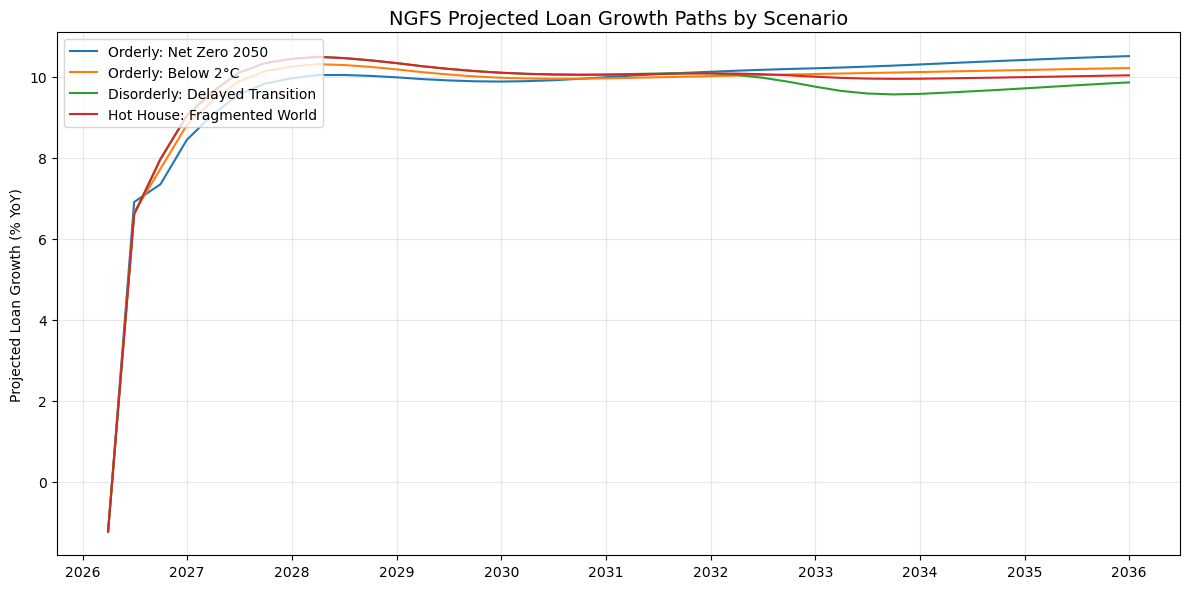

In [44]:
## NGFS LOAN GROWTH path
plt.figure(figsize=(12, 6))
for key in results:
    plt.plot(forecast_dates, results[key].predicted_mean, label=scenarios[key])
plt.title('NGFS Projected Loan Growth Paths by Scenario', fontsize=14)
plt.ylabel('Projected Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




## Var Model

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Apr, 2026
Time:                     22:54:22
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.37105
Nobs:                     278.000    HQIC:                   7.83971
Log likelihood:          -2550.10    FPE:                    1779.93
AIC:                      7.48372    Det(Omega_mle):         1403.76
--------------------------------------------------------------------
Results for equation Loan_Growth
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        0.734547         0.563331            1.304           0.192
L1.Loan_Growth               1.432797         0.064281           22.290           0.000
L1.Unemployment_Rate      

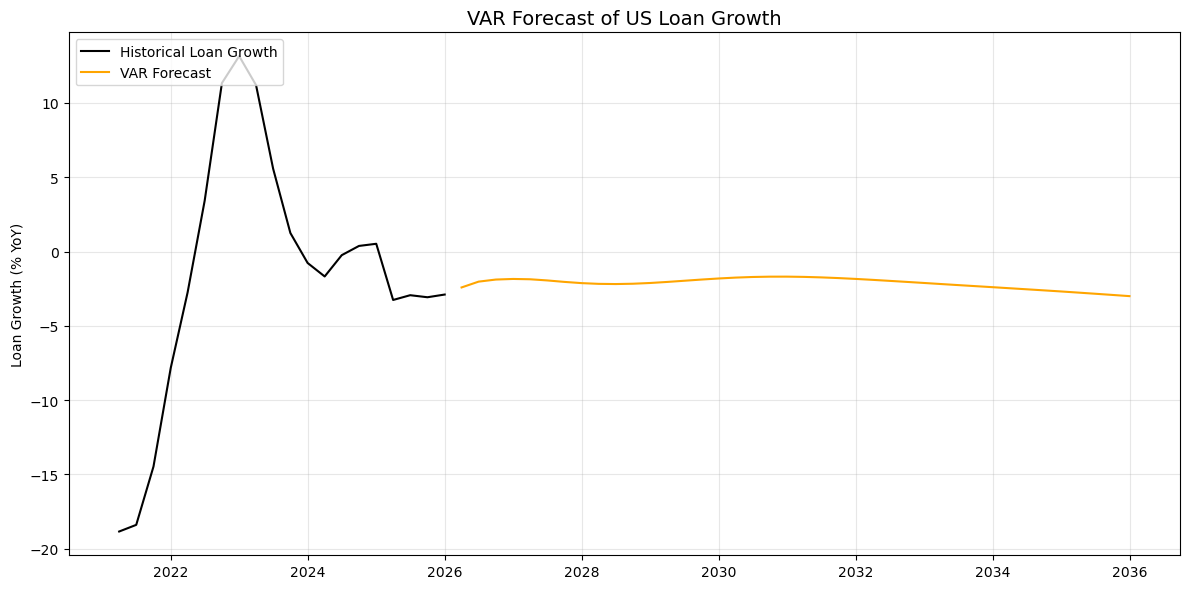

In [37]:
## var model
from statsmodels.tsa.api import VAR
# Prepare data for VAR
var_data = df_history[['Loan_Growth', 'Unemployment_Rate', 'GDP', 'Rates']].dropna()
# Fit VAR model
model_var = VAR(var_data)
results_var = model_var.fit(maxlags=4, ic='aic')
print(results_var.summary())
# Forecast with VAR
lag_order = results_var.k_ar
forecast_input = var_data.values[-lag_order:]
forecast_var = results_var.forecast(y=forecast_input, steps=forecast_steps)
# Convert forecast to DataFrame
forecast_var_df = pd.DataFrame(forecast_var, index=forecast_dates, columns=var_data.columns)
# Plot VAR forecasts
plt.figure(figsize=(12, 6))
plt.plot(var_data.index[-20:], var_data['Loan_Growth'][-20:], label='Historical Loan Growth', color='black')
plt.plot(forecast_var_df.index, forecast_var_df['Loan_Growth'], label='VAR Forecast', color='orange')
plt.title('VAR Forecast of US Loan Growth', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# print var model summary
print(results_var.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Apr, 2026
Time:                     22:54:22
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.37105
Nobs:                     278.000    HQIC:                   7.83971
Log likelihood:          -2550.10    FPE:                    1779.93
AIC:                      7.48372    Det(Omega_mle):         1403.76
--------------------------------------------------------------------
Results for equation Loan_Growth
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        0.734547         0.563331            1.304           0.192
L1.Loan_Growth               1.432797         0.064281           22.290           0.000
L1.Unemployment_Rate      

In [45]:
## give me VAR forecasts for the same NGFS scenarios by replacing the exogenous variables in the VAR forecast with the NGFS paths and re-forecasting the Loan Growth variable
# This is a bit tricky since VAR is a system of equations, but we can do a pseudo-forecast by replacing the exogenous paths and then forecasting one step at a time.
# Get the NGFS paths for the exogenous variables
def get_ngfs_paths(scenario):
    unemp_path = get_ngfs_series(scenario, "Unemployment").loc[forecast_dates[0]:].head(forecast_steps)
    gdp_path = get_ngfs_series(scenario, "Gross Domestic Product").loc[forecast_dates[0]:].head(forecast_steps)
    rates_path = get_ngfs_series(scenario, "Central bank").loc[forecast_dates[0]:].head(forecast_steps)
    return unemp_path, gdp_path, rates_path
# Create a DataFrame to hold the VAR forecasts for each scenario
var_forecasts = pd.DataFrame(index=forecast_dates, columns=scenarios.keys())
for key in scenarios:
    unemp_path, gdp_path, rates_path = get_ngfs_paths(key)
    # Create a DataFrame for the exogenous paths
    exog_df = pd.DataFrame({
        'Unemployment_Rate': last_unemp + unemp_path.values,
        'GDP': last_gdp + gdp_path.values,
        'Rates': last_rates + rates_path.values
    }, index=forecast_dates)
    # Initialize the forecast with the last observed values
    current_values = var_data.iloc[-1].values
    forecasts = []
    for i in range(forecast_steps):
        # Create the input for the VAR model (current values + exogenous paths)
        input_data = np.concatenate([current_values, exog_df.iloc[i].values])
        # Forecast the next step using the VAR coefficients
        next_forecast = results_var.params.values @ input_data
        forecasts.append(next_forecast[0])  # Loan_Growth is the first variable
        current_values = next_forecast  # Update current values for next iteration
    var_forecasts[key] = forecasts
# Plot VAR forecasts for each scenario
plt.figure(figsize=(12, 6))
for key in scenarios:
    plt.plot(var_forecasts.index, var_forecasts[key], label=scenarios[key])
plt.title('VAR Forecast of US Loan Growth by NGFS Scenario', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 7 is different from 4)

In [46]:
## VAR model results
print(results_var.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Apr, 2026
Time:                     23:01:58
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.37105
Nobs:                     278.000    HQIC:                   7.83971
Log likelihood:          -2550.10    FPE:                    1779.93
AIC:                      7.48372    Det(Omega_mle):         1403.76
--------------------------------------------------------------------
Results for equation Loan_Growth
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        0.734547         0.563331            1.304           0.192
L1.Loan_Growth               1.432797         0.064281           22.290           0.000
L1.Unemployment_Rate      

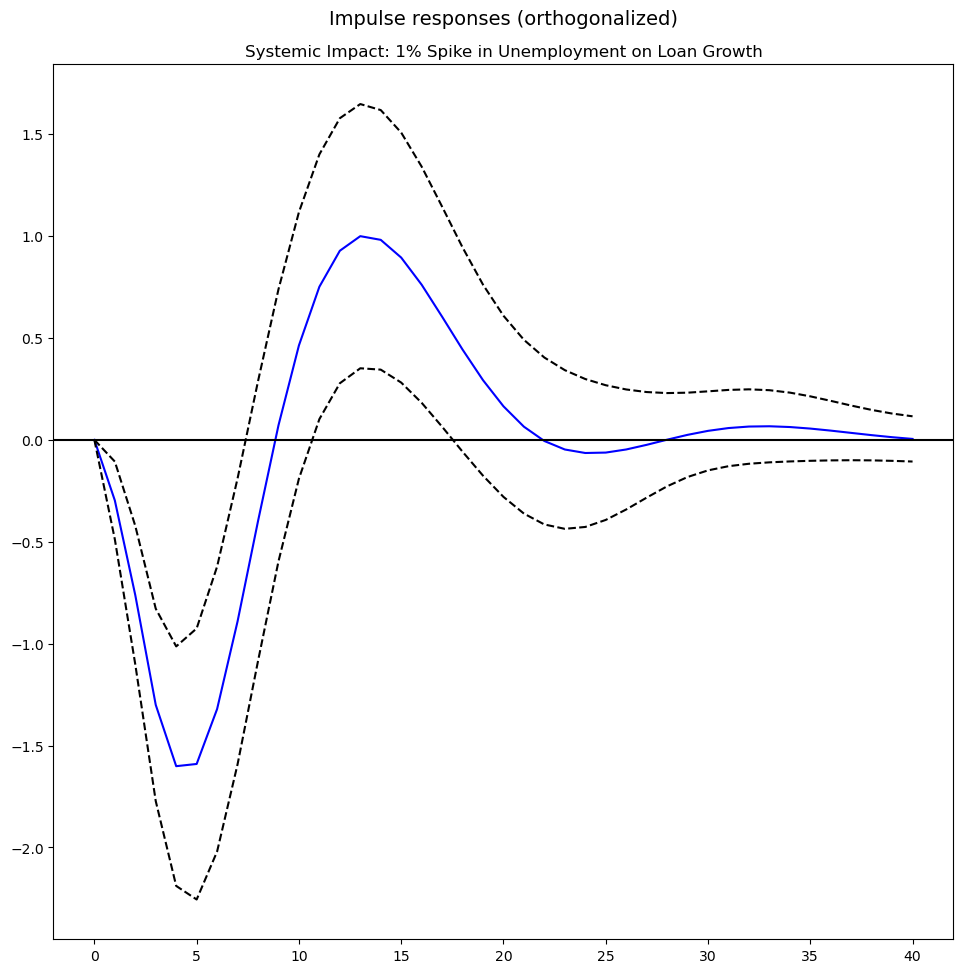

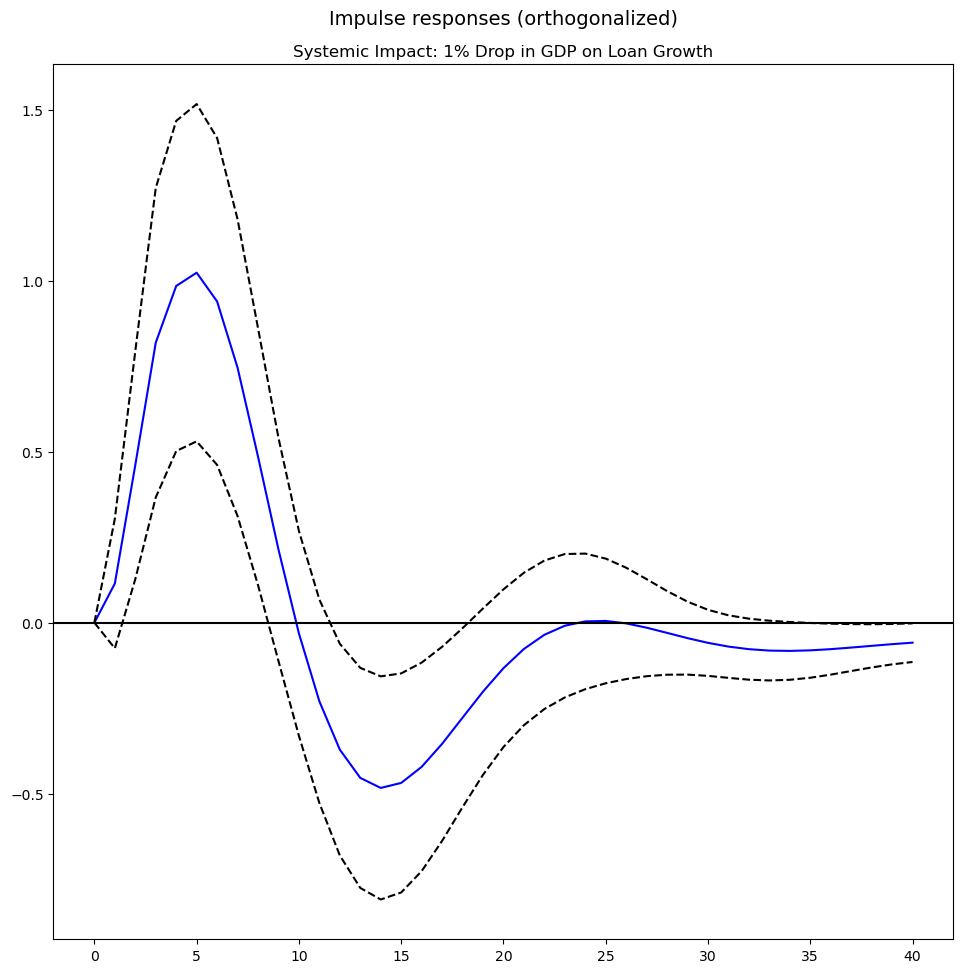

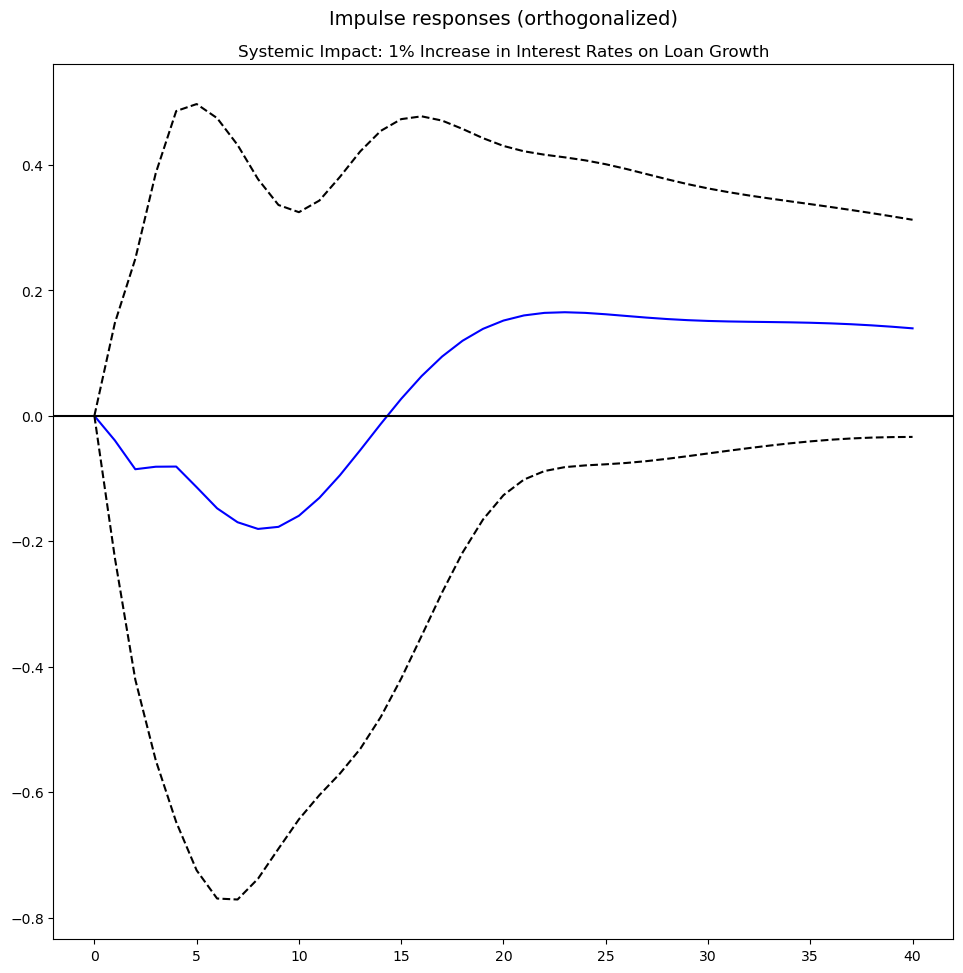

In [47]:
# Create an Impulse Response Function (IRF)
irf = results_var.irf(40) # Look at 40 quarters (10 years)

# Plot the impact of an Unemployment Shock on Loan Growth
irf.plot(impulse='Unemployment_Rate', response='Loan_Growth', orth=True)
plt.title('Systemic Impact: 1% Spike in Unemployment on Loan Growth')
plt.show()
# Plot the impact of a GDP Shock on Loan Growth
irf.plot(impulse='GDP', response='Loan_Growth', orth=True)
plt.title('Systemic Impact: 1% Drop in GDP on Loan Growth')
plt.show()
# Plot the impact of an Interest Rate Shock on Loan Growth
irf.plot(impulse='Rates', response='Loan_Growth', orth=True)
plt.title('Systemic Impact: 1% Increase in Interest Rates on Loan Growth')
plt.show()

In [48]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                    
=======================================================================================
Dep. Variable:                     Loan_Growth   No. Observations:                  282
Model:             ARIMA(2, 0, 0)x(1, 0, 0, 4)   Log Likelihood                -559.465
Date:                         Sat, 04 Apr 2026   AIC                           1134.930
Time:                                 23:02:00   BIC                           1164.065
Sample:                             09-30-1955   HQIC                          1146.613
                                  - 12-31-2025                                         
Covariance Type:                           opg                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                17.2941      4.413      3.919      0.000       8.645      25.943
Unemployment_Lag1    -1.6379      0.505     -3.242      0.001      -2.628      -0.648
GDP_Lag1             -0.0003      0.000     -1.743      0.081      -0.001    4.23e-05
Rates_Lag1            0.3665      0.106      3.444      0.001       0.158       0.575
ar.L1                 1.4948      0.067     22.424      0.000       1.364       1.625
ar.L2                -0.6024      0.065     -9.205      0.000      -0.731      -0.474
ar.S.L4              -0.1936      0.095     -2.041      0.041      -0.379      -0.008
sigma2                4.5228      0.573      7.897      0.000       3.400       5.645
===================================================================================
Ljung-Box (L1) (Q):                   1.59   Jarque-Bera (JB):                 7.32
Prob(Q):                              0.21   Prob(JB):                         0.03
Heteroskedasticity (H):               1.46   Skew:                            -0.16
Prob(H) (two-sided):                  0.07   Kurtosis:                         3.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [49]:
## 9. EVALUATE SCENARIO DIFFERENCES
# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Date': pred_delayed.index,
    'Delayed_Transition': pred_delayed.values,
    'Below_2C': pred_stress.values,
    'Net_Zero_2050': p_nz.values,
    'Fragmented_World': pred_fragmented.values
})
# Calculate differences between scenarios
summary_df['Delayed_vs_2C'] = summary_df['Delayed_Transition'] - summary_df['Below_2C']
summary_df['Delayed_vs_NZ'] = summary_df['Delayed_Transition'] - summary_df['Net_Zero_2050']
summary_df['2C_vs_NZ'] = summary_df['Below_2C'] - summary_df['Net_Zero_2050']
summary_df['Fragmented_vs_Delayed'] = summary_df['Fragmented_World'] - summary_df['Delayed_Transition']
summary_df['Fragmented_vs_2C'] = summary_df['Fragmented_World'] - summary_df['Below_2C']
summary_df['Fragmented_vs_NZ'] = summary_df['Fragmented_World'] - summary_df['Net_Zero_2050']
print(summary_df.head())


        Date  Delayed_Transition   Below_2C  Net_Zero_2050  Fragmented_World  \
0 2026-06-30            6.607964   6.607964       6.607964          6.607964   
1 2026-09-30            9.489115   9.489115       9.489115          9.489115   
2 2026-12-31           11.491143  11.353313      11.052495         11.491240   
3 2027-03-31           11.321859  11.187463      10.896655         11.321884   
4 2027-06-30           11.048341  10.917591      10.636471         11.048299   

   Delayed_vs_2C  Delayed_vs_NZ  2C_vs_NZ  Fragmented_vs_Delayed  \
0       0.000000       0.000000  0.000000               0.000000   
1       0.000000       0.000000  0.000000               0.000000   
2       0.137830       0.438648  0.300818               0.000097   
3       0.134396       0.425204  0.290807               0.000025   
4       0.130749       0.411869  0.281120              -0.000041   

   Fragmented_vs_2C  Fragmented_vs_NZ  
0          0.000000          0.000000  
1          0.000000          0

In [50]:
## model validation using backtesting on historical data
# Backtesting with Walk-Forward Validation  
from sklearn.metrics import mean_absolute_error
# We will use the last 10 years for backtesting
backtest_start = df_train.index[-40]  # Last 5 years (20 quarters)
# Store predictions and actuals
backtest_predictions = []
backtest_actuals = []
# Walk-forward loop
for i in range(40, len(df_train)):
    # Train on data up to the current point
    train_data = df_train.iloc[:i]
    y_train = train_data['Loan_Growth']
    X_train = train_data[['Unemployment_Lag1']]
    
    # Fit model
    model_bt = ARIMA(y_train, exog=X_train, order=(2, 0, 2))
    model_fit_bt = model_bt.fit()
    
    # Predict the next quarter
    X_next = df_train.iloc[i][['Unemployment_Lag1']].values.reshape(1, -1)
    pred_next = model_fit_bt.get_forecast(steps=1, exog=X_next).predicted_mean[0]
    
    # Store prediction and actual
    backtest_predictions.append(pred_next)
    backtest_actuals.append(df_train['Loan_Growth'].iloc[i])
# Calculate MAE
mae = mean_absolute_error(backtest_actuals, backtest_predictions)
print(f"Backtesting MAE: {mae:.4f}")
# calculat relative error
relative_errors = np.abs(np.array(backtest_predictions) - np.array(backtest_actuals)) / np.abs(backtest_actuals)
average_relative_error = np.mean(relative_errors)
print(f"Average Relative Error: {average_relative_error:.4f}")

Backtesting MAE: 1.3111
Average Relative Error: 0.4615


In [ ]:
# Create a series for the dates corresponding to the backtest
# Since your loop starts at index 20, the dates start there too
backtest_dates = df_train.index[40:]

plt.figure(figsize=(12, 6))

# Plot Actuals
plt.plot(backtest_dates, backtest_actuals, label='Actual Loan Growth', color='black', linewidth=2)

# Plot Predictions
plt.plot(backtest_dates, backtest_predictions, label='Walk-Forward Prediction', color='orange', linestyle='--', linewidth=1.5)

plt.title(f'Model Validation: Walk-Forward Backtest (MAE: {mae:.2f}%)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
## pull out autocorrelation and partial autocorrelation plots to check for remaining patterns in the residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(residuals, ax=plt.gca(), lags=20)
plt.subplot(212)
plot_pacf(residuals, ax=plt.gca(), lags=20)
plt.show()

## Ignore Below

In [ ]:
physicaldata = pd.read_excel('/Users/geoffpoint-du-jour/Downloads/Forecasting/ECON-522-Forecasting-Project/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx')

In [ ]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear') 

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

In [ ]:
ngfs_quarterly.head()

In [ ]:
## implement ngfs_quarterly into our forecasting model as additional features to see if they improve the forecasts
# Merge NGFS data with historical data
df_model = df_history.merge(ngfs_quarterly, left_index=True, right_index=True, how='left')
# We will use the same target (Loan Growth) but now with additional features from NGFS
# Define target and features
target = 'Loan_Growth'
features = ['Unemployment_Lag1'] + [col for col in ngfs_quarterly.columns if 'combined' in col]
# drop na
df_model = df_model.dropna(subset=[target] + features)
# Train/Test Split
from sklearn.model_selection import train_test_split
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Train ARIMA with exogenous variables (NGFS features)
model_ngfs = ARIMA(y_train, exog=X_train, order=(2, 0, 2))
model_fit_ngfs = model_ngfs.fit()
print(model_fit_ngfs.summary())
# Forecast on test set
forecast_ngfs = model_fit_ngfs.get_forecast(steps=len(X_test), exog=X_test)
pred_ngfs = forecast_ngfs.predicted_mean
# Evaluate
from sklearn.metrics import mean_absolute_error
mae_ngfs = mean_absolute_error(y_test, pred_ngfs)
print(f"MAE with NGFS features: {mae_ngfs:.4f}")
# Compare with original model (without NGFS features)
model_original = ARIMA(y_train, exog=X_train[['Unemployment_Lag1']], order=(2, 0, 2))
model_fit_original = model_original.fit()
forecast_original = model_fit_original.get_forecast(steps=len(X_test), exog=X_test[['Unemployment_Lag1']])
pred_original = forecast_original.predicted_mean
mae_original = mean_absolute_error(y_test, pred_original)
print(f"MAE without NGFS features: {mae_original:.4f}")


In [ ]:
# ---------------------------------------------------------
# 6. LOAD & PROCESS NGFS (WIDE FORMAT CONVERSION)
# ---------------------------------------------------------
print("\nProcessing NGFS Scenarios (Wide Format)...")

# ==============================================================================
# A. CONFIGURATION (Updated for NiGEM/NGFS Structure)
# ==============================================================================
# Point to your NiGEM or Downscaled NGFS CSV
file_path = 'NiGEM_data.xlsx'

# Typical NGFS strings - update these if your specific file uses different ones
TARGET_REGION = 'United States' 

# Variables often appear as 'Unemployment Rate' or 'Price|Consumer Price Index'
VAR_UNEMP = 'Unemployment Rate' 
VAR_INFL  = 'Inflation Rate'    

# Scenarios often include a prefix like 'NGFS Phase 4' or 'Disorderly'
SCENARIO_DELAYED = 'Delayed transition'
SCENARIO_NETZERO = 'Net Zero 2050'
# ==============================================================================

try:
    # 1. Load Raw Data with Latin-1 encoding to fix UnicodeDecodeError
    df_raw = pd.read_csv(file_path, encoding='latin-1')
    print(f"✅ Loaded {file_path}. Rows: {len(df_raw)}")
    
    # Strip whitespace from string columns to prevent matching errors
    string_cols = ['Region', 'Variable', 'Scenario']
    for col in string_cols:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].astype(str).str.strip()

    # 2. Filter for Region
    df_reg = df_raw[df_raw['Region'] == TARGET_REGION].copy()
    if df_reg.empty:
        print(f"❌ ERROR: No data found for Region '{TARGET_REGION}'.")
        print("Available Regions:", df_raw['Region'].unique()[:5])
        raise ValueError("Region Not Found")

    # 3. Flexible Extract Function
    def extract_scenario_series(df, scenario_name, var_name):
        # We use str.contains in case there are prefixes like 'Phase 4 | Delayed transition'
        mask = (df['Scenario'].str.contains(scenario_name, case=False, na=False)) & \
               (df['Variable'].str.contains(var_name, case=False, na=False))
        row = df[mask]
        
        if row.empty:
            return None
        
        # Identify year columns (e.g., '2022', '2023'...)
        year_cols = [c for c in df.columns if c.isdigit()]
        ts_data = row[year_cols].T
        ts_data.columns = ['Value']
        ts_data.index.name = 'Year'
        return pd.to_numeric(ts_data['Value'], errors='coerce')

    # 4. Extract Data
    s_unemp_delayed = extract_scenario_series(df_reg, SCENARIO_DELAYED, VAR_UNEMP)
    s_infl_delayed  = extract_scenario_series(df_reg, SCENARIO_DELAYED, VAR_INFL)
    s_unemp_netzero = extract_scenario_series(df_reg, SCENARIO_NETZERO, VAR_UNEMP)
    s_infl_netzero  = extract_scenario_series(df_reg, SCENARIO_NETZERO, VAR_INFL)

    # 5. Build cleaned Scenario DataFrame
    df_ngfs_clean = pd.DataFrame({
        'Unemp_Delayed': s_unemp_delayed,
        'Infl_Delayed': s_infl_delayed,
        'Unemp_NetZero': s_unemp_netzero,
        'Infl_NetZero': s_infl_netzero
    }).dropna()

    if df_ngfs_clean.empty:
        raise ValueError("Could not find matching Scenarios/Variables. Check debug info below.")

    # 6. Convert Index to Datetime & Resample to Quarterly
    df_ngfs_clean.index = pd.to_datetime(df_ngfs_clean.index.astype(str) + '-12-31')
    
    # Quarterly interpolation
    future_dates = pd.date_range(start=df_train.index[-1], periods=21, freq='QE')[1:]
    df_ngfs_q = df_ngfs_clean.resample('QE').asfreq().interpolate(method='linear')
    df_ngfs_future = df_ngfs_q.reindex(future_dates).fillna(method='ffill')
    
    print("✅ NGFS Data successfully prepared.")
    print(df_ngfs_future.head())

except Exception as e:
    print(f"❌ Error: {e}")
    if 'df_raw' in locals():
        print("\n--- DEBUG INFO ---")
        print("Variables in CSV:", df_raw['Variable'].unique()[:10])
        print("Scenarios in CSV:", df_raw['Scenario'].unique()[:5])

In [ ]:
X_future_delayed = pd.DataFrame(index=future_dates)
X_future_delayed['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                    df_history['Unemployment_Rate'].iloc[-1]+0.5,
                                                    steps)

# Stress Scenario: Below 2°C Transition Shock (high stress)
X_future_stress = pd.DataFrame(index=future_dates)
X_future_stress['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                   df_history['Unemployment_Rate'].iloc[-1]+4.0,
                                                   steps)

In [ ]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear') 

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

In [ ]:
# Define the forecast window 
forecast_steps = 20 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='Q')[1:]

# Extract the NGFS Unemployment column for Net Zero 2050
# Reminder: NiGEM values are SHOCKS (e.g., +1.5 means 1.5% higher than baseline)
nz_unemp_shock = ngfs_quarterly.loc[forecast_dates[0]:, 'Net Zero 2050_Unemployment rate ; %(combined)'].head(forecast_steps)
# Extract the NGFS Unemployment column for Delayed Transition
delayed_unemp_shock = ngfs_quarterly.loc[forecast_dates[0]:, 'Delayed transition_Unemployment rate ; %(combined)'].head(forecast_steps)



# Anchor the shock to the last historical FRED data point
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]
future_unemp_path = last_actual_unemp + nz_unemp_shock
# For Delayed Transition scenario
future_unemp_path_delayed = last_actual_unemp + delayed_unemp_shock


# Combine history + future to calculate rolling features without a 'break' at the start
full_series = pd.concat([df_history['Unemployment_Rate'], future_unemp_path,])
full_series_delayed = pd.concat([df_history['Unemployment_Rate'], future_unemp_path_delayed])
# Create the future Exogenous DataFrame
X_future_nz = pd.DataFrame(index=forecast_dates)
X_future_nz['Unemployment_Lag1'] = full_series.shift(1).loc[forecast_dates]




# Generate the forecast
# steps must match the number of rows in X_future_nz
nz_forecast = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
pred_delayed = forecast_delayed.predicted_mean 

# Extract the results
p_nz = nz_forecast.predicted_mean
conf_nz = nz_forecast.conf_int()
# Plotting
plt.figure(figsize=(12, 6))
# Historical Loan Growth
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)
# Delayed Transition Scenario
plt.plot(pred_delayed.index, pred_delayed, label='Scenario: Delayed Transition (Unemp=4%)', color='green', linestyle='--', linewidth=2)
# Below 2°C Transition Shock
plt.plot(pred_stress.index, pred_stress, label='Scenario: Below 2°C (Unemp->8%)', color='red', linestyle='--', linewidth=2)
# Net Zero 2050 Scenario (NGFS)
plt.plot(p_nz.index, p_nz, label='Scenario: Net Zero 2050 (NGFS)', color='blue', linestyle='--', linewidth=2)
# Confidence Interval for Net Zero Scenario
plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)
plt.title('Climate Stress Test: Adding NGFS Net Zero 2050 Scenario', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## SVAR

In [ ]:
from statsmodels.tsa.vector_ar.var_model import VAR
import numpy as np

# 1. Prepare the endogenous matrix (Order matters for Cholesky!)
# Common order: GDP -> Unemployment -> Rates -> Loan_Growth
# Logic: Real economy moves first, Central Bank reacts, Banks adjust lending last.
df_svar = df_train[['GDP', 'Unemployment_Rate', 'Rates', 'Loan_Growth']].dropna()

# 2. Estimate the reduced-form VAR first
model_var = VAR(df_svar)
results_var = model_var.fit(maxlags=3, ic='bic')

# 3. Define Structural Restrictions (A matrix)
# We use a lower triangular matrix for a Cholesky identification
# This means Variable 1 affects all, but Variable 4 only affects itself initially.
a_matrix = np.array([
    [1, 0, 0, 0],
    ['E', 1, 0, 0],
    ['E', 'E', 1, 0],
    ['E', 'E', 'E', 1]
])

# 4. Fit the SVAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
model_svar = SVAR(df_svar, svar_type='A', A=a_matrix)
results_svar = model_svar.fit(maxlags=3)

# 5. Generate Structural Impulse Responses (The Stress Test)
# This shows how a 'Climate Shock' to GDP ripples through to Loans
irf = results_svar.irf(20)
irf.plot(impulse='GDP', response='Loan_Growth', orth=False)

In [ ]:
def project_svar_scenario(scenario_name, steps=20):
    # 1. Get NGFS paths for the 3 macro drivers
    X_future = build_ngfs_exog_multi(scenario_name) 
    
    # 2. Get the last 'k_ar' observations (lags) from your training data
    # results_svar.k_ar should be 3 based on your previous code
    lags = results_svar.k_ar
    history = df_svar.values[-lags:]
    
    svar_results = []
    
    for i in range(steps):
        # 3. Predict the next step
        # We use results_svar.forecast directly
        next_step = results_svar.forecast(history, steps=1)
        
        # 4. KEY STEP: Override the predicted Macro values with NGFS 'True' Scenario values
        # Column Order: [0: GDP, 1: Unemployment_Rate, 2: Rates, 3: Loan_Growth]
        ngfs_row = X_future.iloc[i]
        
        # Update the forecast with scenario-specific values
        next_step[0, 0] = ngfs_row['GDP_Lag1'] 
        next_step[0, 1] = ngfs_row['Unemployment_Lag2']
        next_step[0, 2] = ngfs_row['Rates_Lag1']
        
        # 5. Store the result (which now has the 'forced' macro + 'calculated' loans)
        svar_results.append(next_step[0])
        
        # 6. Update history: slide the window forward
        history = np.vstack([history[1:], next_step])
        
    return pd.DataFrame(svar_results, columns=df_svar.columns, index=forecast_dates)

In [ ]:
## project svar scenarios 
svar_nz = project_svar_scenario("Net Zero 2050")
svar_delayed = project_svar_scenario("Delayed transition")
# Plotting SVAR Projections
plt.figure(figsize=(12, 6))
plt.plot(svar_nz.index, svar_nz['Loan_Growth'], label='SVAR Projection: Net Zero 2050', color='blue')
plt.plot(svar_delayed.index, svar_delayed['Loan_Growth'], label='SVAR Projection: Delayed Transition', color='green')
plt.title('SVAR Projected Loan Growth under NGFS Scenarios', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()